# 🩺 Multi-Class Diabetes Prediction using Machine Learning

## Dataset
Behavioral Risk Factor Surveillance System (BRFSS) 2021

## Goal
Predict whether a patient belongs to one of the following classes:

- 0 → No Diabetes
- 1 → Prediabetes
- 2 → Diabetes

This project compares multiple machine learning algorithms, performs hyperparameter tuning, explains predictions using SHAP, and saves the best-performing model for deployment.

In [1]:
!pip install -q \
xgboost \
lightgbm \
catboost \
optuna \
shap \
imbalanced-learn \
plotly \
missingno

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import missingno as msno

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"]=(10,6)
plt.rcParams["font.size"]=12

In [3]:
import pandas as pd

df = pd.read_csv('/content/diabetes_012_health_indicators_BRFSS2021.csv')


In [4]:
print("="*60)
print("Dataset Shape")
print("="*60)

print(df.shape)

print()

print("="*60)
print("First Five Rows")
print("="*60)

display(df.head())

Dataset Shape
(236378, 22)

First Five Rows


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,0,1.0,1,15.0,1.0,0.0,0.0,0,1,...,1,0.0,5.0,10.0,20.0,0.0,0,11,4.0,5.0
1,2.0,1,0.0,1,28.0,0.0,0.0,1.0,0,1,...,1,0.0,2.0,0.0,0.0,0.0,0,11,4.0,3.0
2,2.0,1,1.0,1,33.0,0.0,0.0,0.0,1,1,...,1,0.0,2.0,10.0,0.0,0.0,0,9,4.0,7.0
3,2.0,0,1.0,1,29.0,0.0,1.0,1.0,1,1,...,1,0.0,5.0,0.0,30.0,1.0,1,12,3.0,4.0
4,0.0,0,0.0,1,24.0,1.0,0.0,0.0,0,0,...,1,0.0,3.0,0.0,0.0,1.0,1,13,5.0,6.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236378 entries, 0 to 236377
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          236378 non-null  float64
 1   HighBP                236378 non-null  int64  
 2   HighChol              236378 non-null  float64
 3   CholCheck             236378 non-null  int64  
 4   BMI                   236378 non-null  float64
 5   Smoker                236378 non-null  float64
 6   Stroke                236378 non-null  float64
 7   HeartDiseaseorAttack  236378 non-null  float64
 8   PhysActivity          236378 non-null  int64  
 9   Fruits                236378 non-null  int64  
 10  Veggies               236378 non-null  int64  
 11  HvyAlcoholConsump     236378 non-null  int64  
 12  AnyHealthcare         236378 non-null  int64  
 13  NoDocbcCost           236378 non-null  float64
 14  GenHlth               236378 non-null  float64
 15  

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_012,236378.0,0.307791,0.705037,0.0,0.0,0.0,0.0,2.0
HighBP,236378.0,0.418558,0.493324,0.0,0.0,0.0,1.0,1.0
HighChol,236378.0,0.402059,0.490315,0.0,0.0,0.0,1.0,1.0
CholCheck,236378.0,0.963347,0.187909,0.0,1.0,1.0,1.0,1.0
BMI,236378.0,28.953579,6.552055,12.0,24.0,28.0,32.0,99.0
Smoker,236378.0,0.411997,0.492196,0.0,0.0,0.0,1.0,1.0
Stroke,236378.0,0.038900,0.193356,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,236378.0,0.086548,0.281172,0.0,0.0,0.0,0.0,1.0
PhysActivity,236378.0,0.779231,0.414766,0.0,1.0,1.0,1.0,1.0
Fruits,236378.0,0.621259,0.485074,0.0,0.0,1.0,1.0,1.0


In [7]:
df.isnull().sum()

,0
Diabetes_012,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0


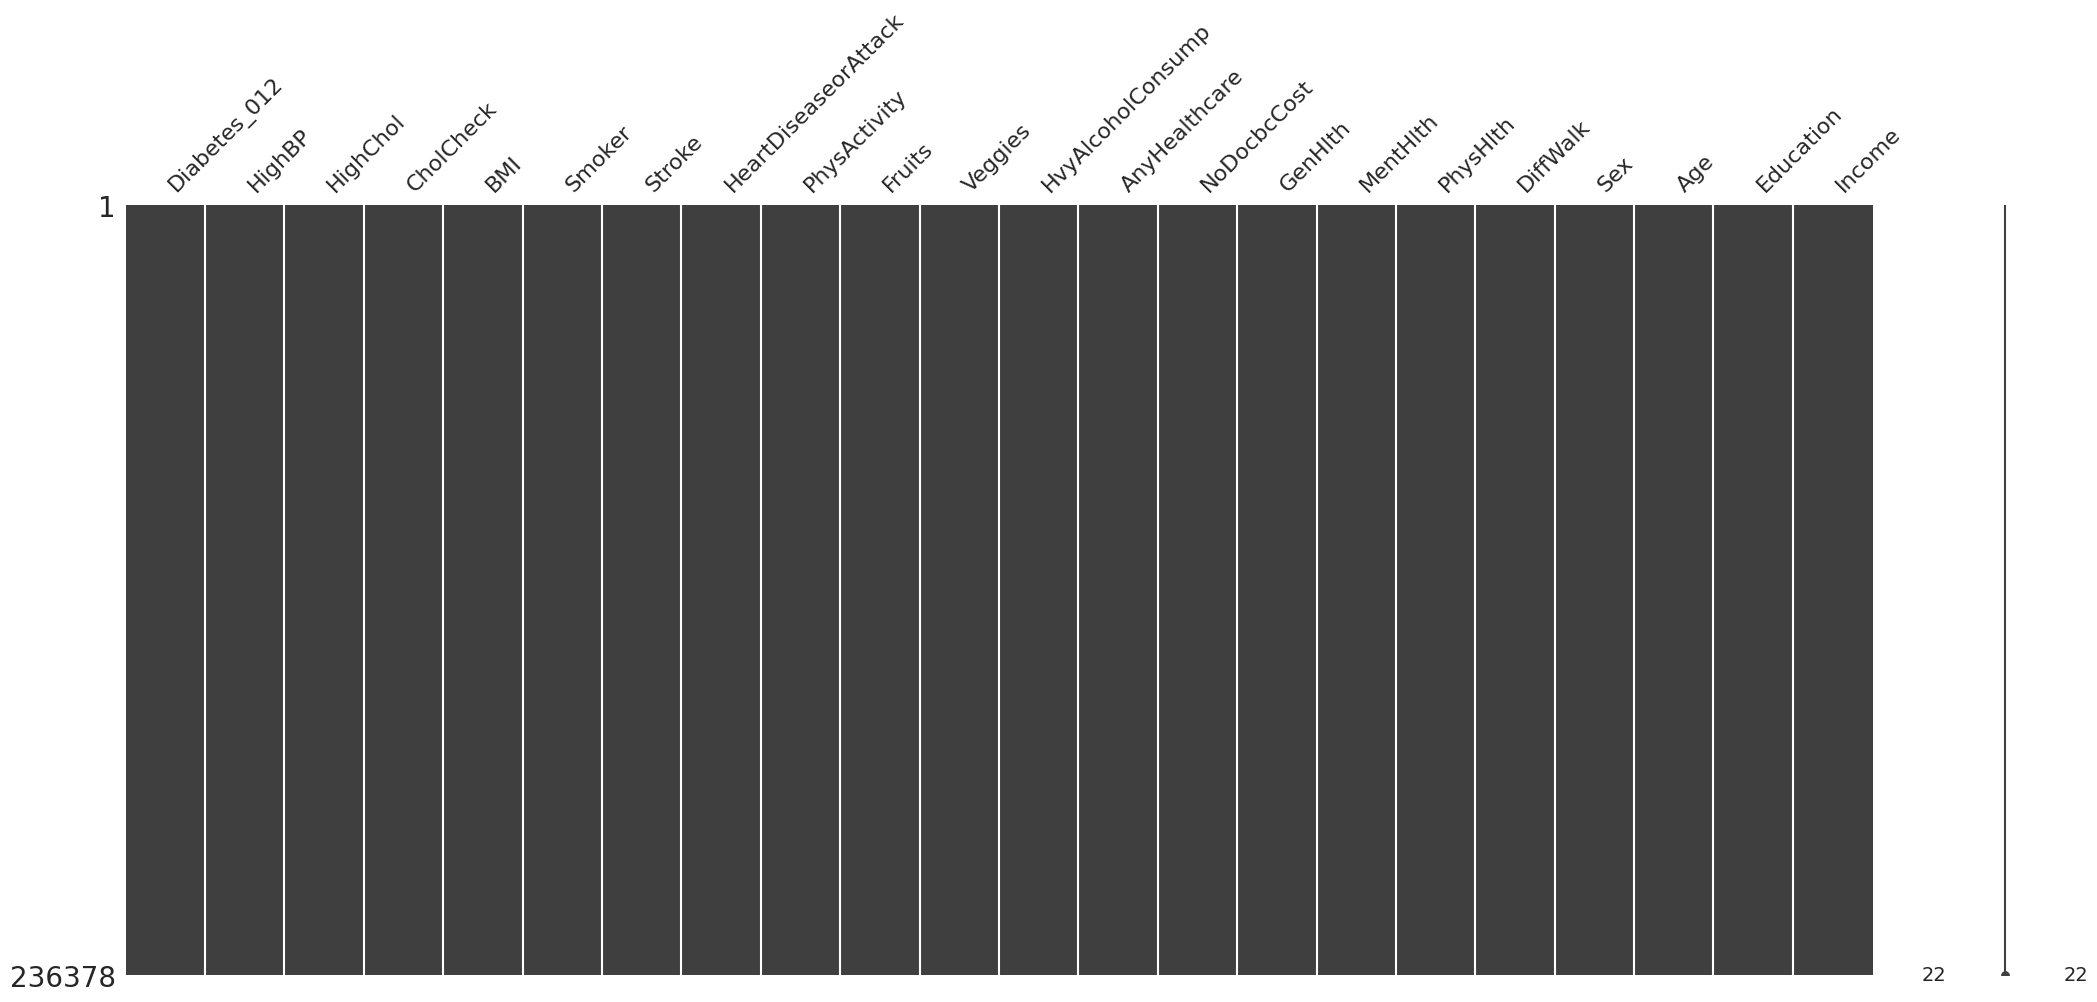

In [8]:
msno.matrix(df)
plt.show()

In [9]:
print("Duplicate Rows :",df.duplicated().sum())

Duplicate Rows : 12828


In [10]:
df = df.drop_duplicates()

print(df.shape)

(223550, 22)


In [11]:
df.columns = [
'Diabetes',
'HighBP',
'HighChol',
'CholCheck',
'BMI',
'Smoker',
'Stroke',
'HeartDisease',
'PhysActivity',
'Fruits',
'Veggies',
'HvyAlcoholConsump',
'AnyHealthcare',
'NoDocbcCost',
'GenHlth',
'MentHlth',
'PhysHlth',
'DiffWalk',
'Sex',
'Age',
'Education',
'Income'
]

In [12]:
df["Diabetes"].value_counts()

,count
Diabetes,
0.0,184542
2.0,33395
1.0,5613


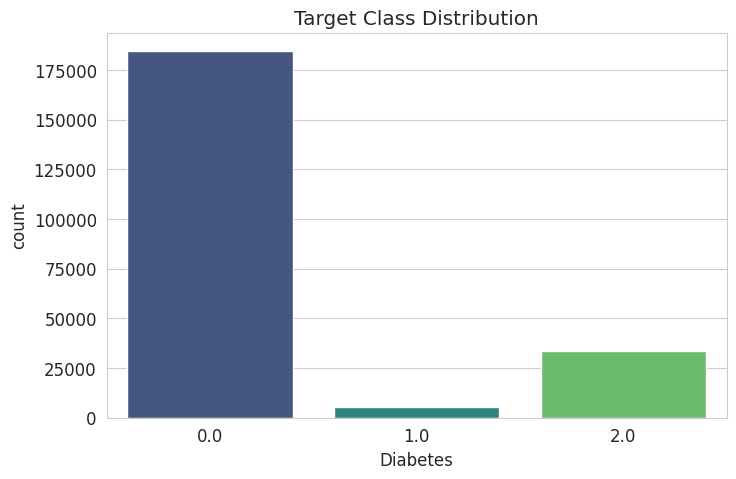

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Diabetes",
    palette="viridis"
)

plt.title("Target Class Distribution")

plt.show()

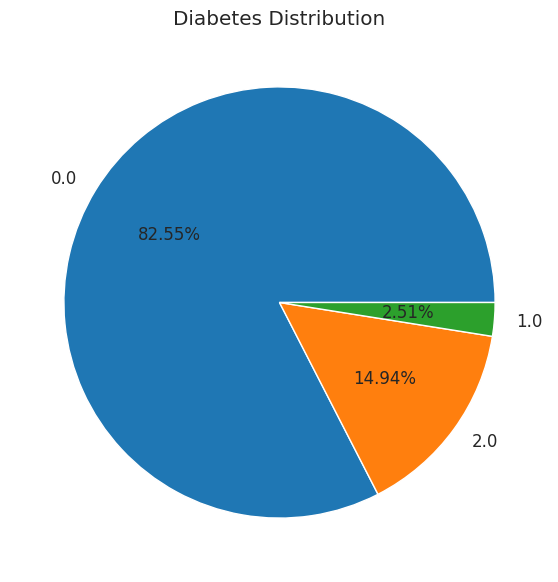

In [14]:
df["Diabetes"].value_counts().plot(
    kind="pie",
    autopct="%1.2f%%",
    figsize=(7,7)
)

plt.ylabel("")
plt.title("Diabetes Distribution")
plt.show()

In [15]:
numeric = [
'BMI',
'MentHlth',
'PhysHlth'
]

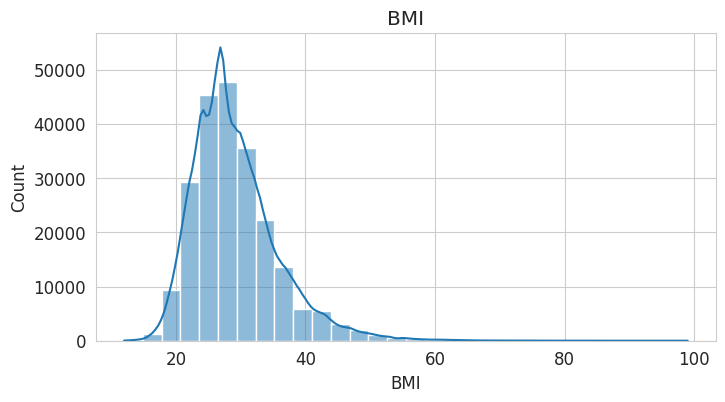

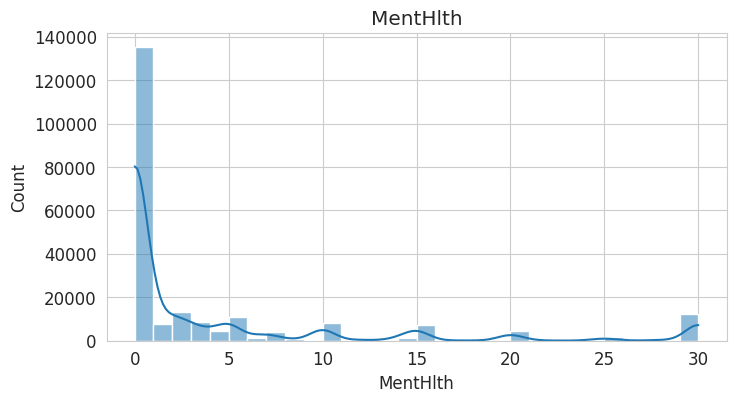

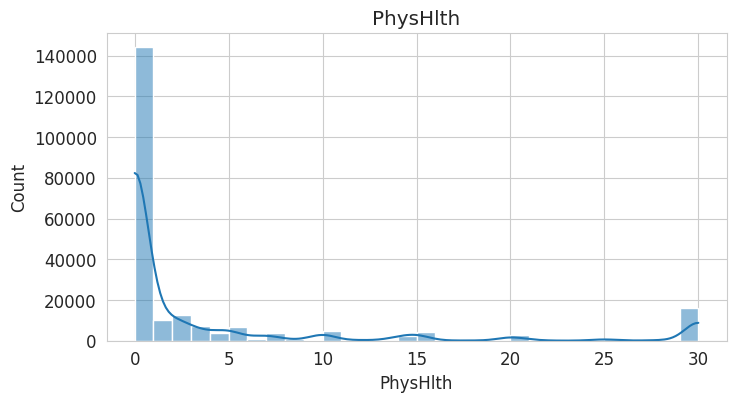

In [16]:
for col in numeric:

    plt.figure(figsize=(8,4))

    sns.histplot(
        df[col],
        kde=True,
        bins=30
    )

    plt.title(col)

    plt.show()

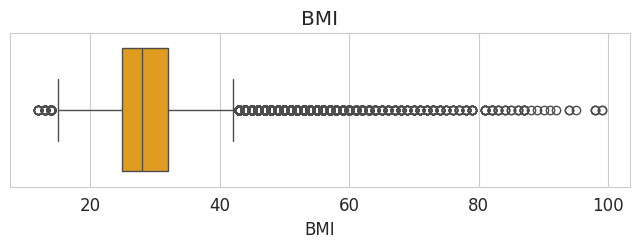

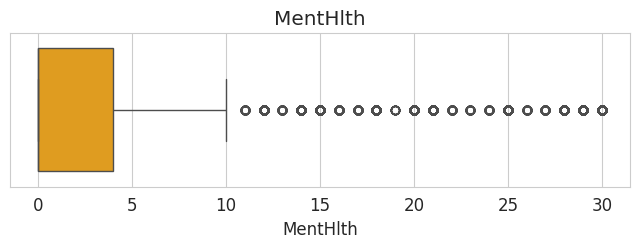

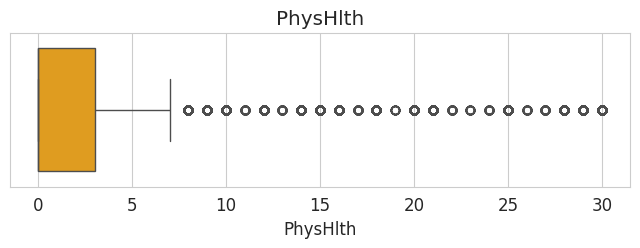

In [17]:
for col in numeric:

    plt.figure(figsize=(8,2))

    sns.boxplot(
        x=df[col],
        color="orange"
    )

    plt.title(col)

    plt.show()

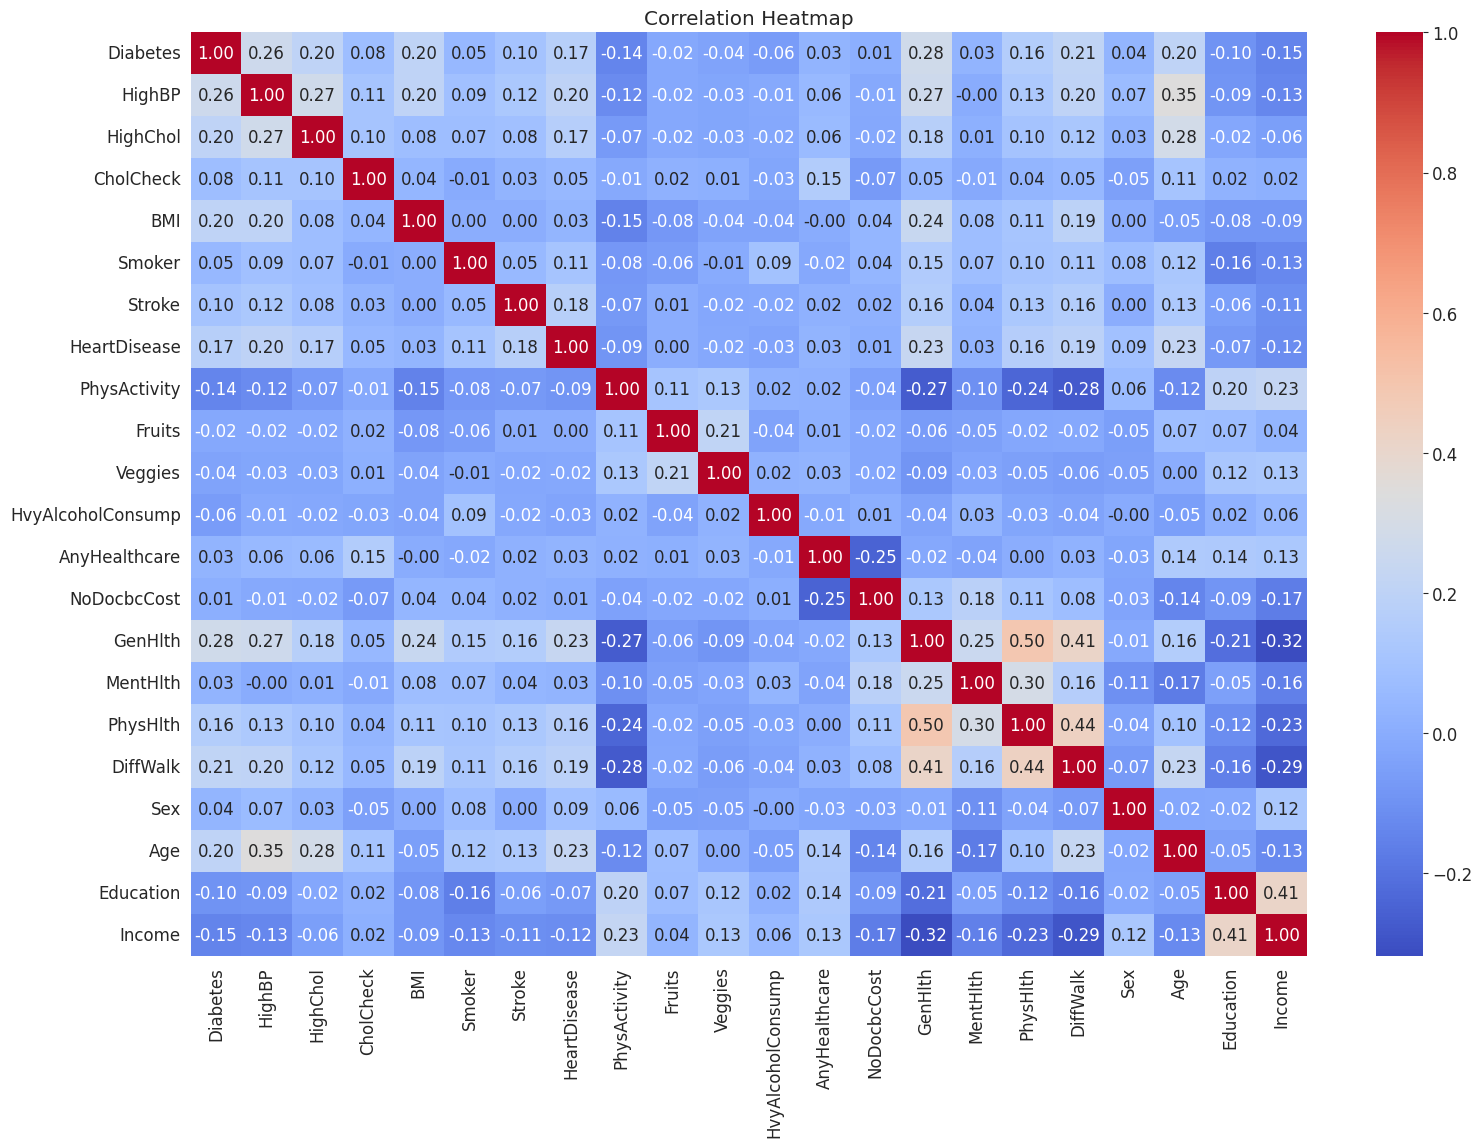

In [18]:
plt.figure(figsize=(18,12))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [19]:
corr = df.corr()["Diabetes"]

corr = corr.sort_values(ascending=False)

corr

,Diabetes
Diabetes,1.000000
GenHlth,0.278590
HighBP,0.263919
DiffWalk,0.209250
HighChol,0.204422
BMI,0.204167
Age,0.201837
HeartDisease,0.172779
PhysHlth,0.155713
Stroke,0.098964


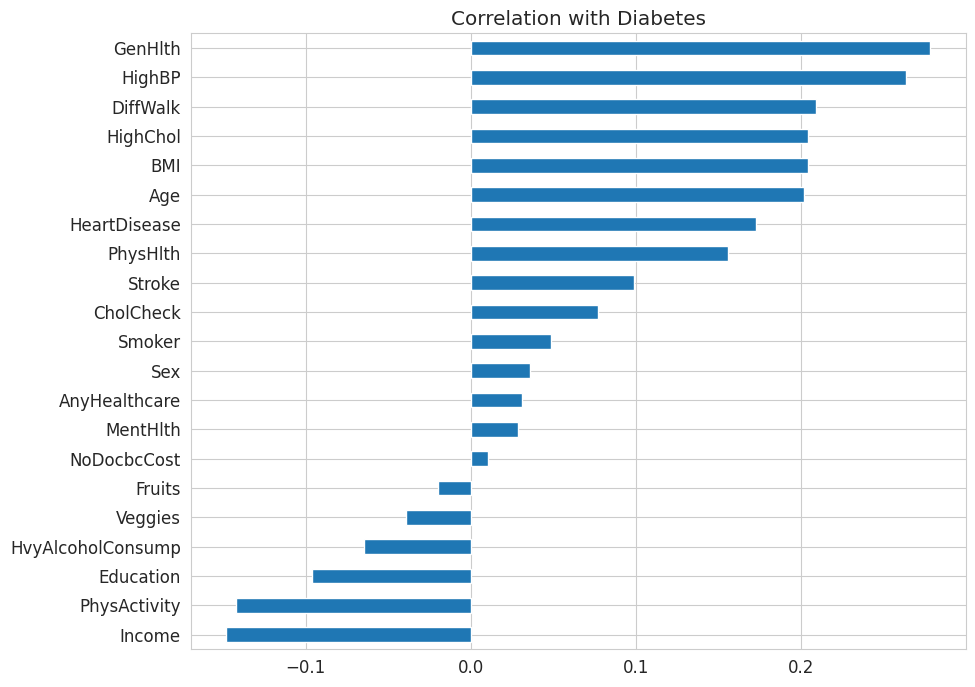

In [20]:
corr = corr.drop("Diabetes")

plt.figure(figsize=(10,8))

corr.sort_values().plot.barh()

plt.title("Correlation with Diabetes")

plt.show()

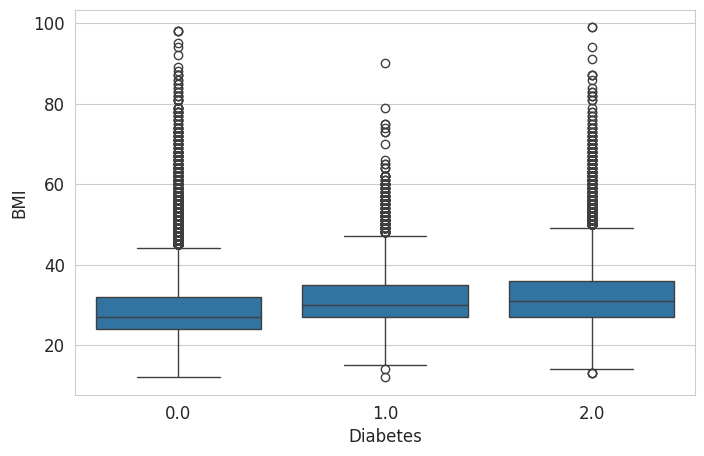

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Diabetes",
    y="BMI"
)

plt.show()

In [22]:
from sklearn.feature_selection import mutual_info_classif

X = df.drop("Diabetes",axis=1)

y = df["Diabetes"]

mi = mutual_info_classif(X,y)

mi = pd.Series(mi,index=X.columns)

mi = mi.sort_values(ascending=False)

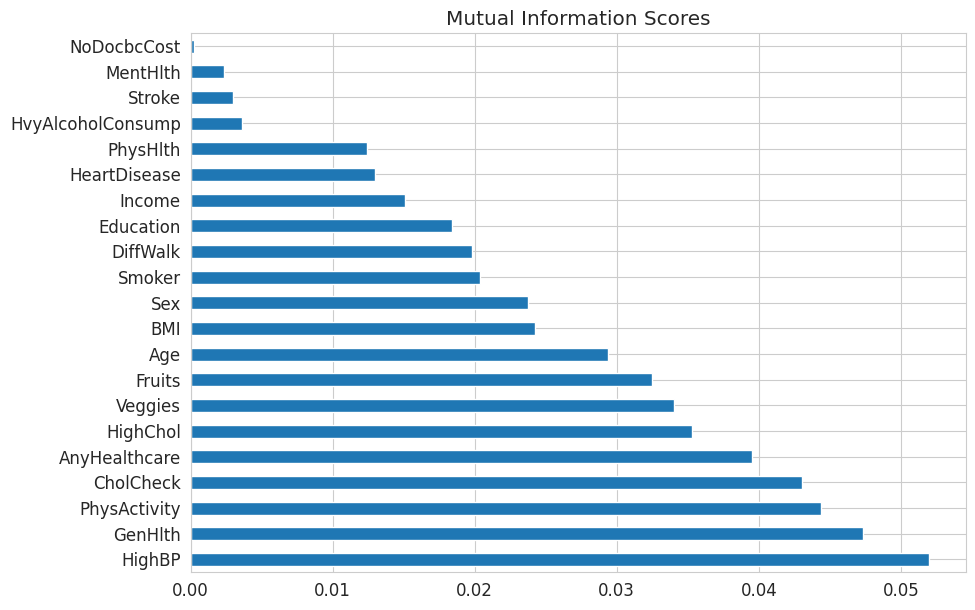

In [23]:
plt.figure(figsize=(10,7))

mi.plot.barh()

plt.title("Mutual Information Scores")

plt.show()

In [24]:
display(df.head())

print(df.shape)

,Diabetes,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDisease,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,0,1.0,1,15.0,1.0,0.0,0.0,0,1,...,1,0.0,5.0,10.0,20.0,0.0,0,11,4.0,5.0
1,2.0,1,0.0,1,28.0,0.0,0.0,1.0,0,1,...,1,0.0,2.0,0.0,0.0,0.0,0,11,4.0,3.0
2,2.0,1,1.0,1,33.0,0.0,0.0,0.0,1,1,...,1,0.0,2.0,10.0,0.0,0.0,0,9,4.0,7.0
3,2.0,0,1.0,1,29.0,0.0,1.0,1.0,1,1,...,1,0.0,5.0,0.0,30.0,1.0,1,12,3.0,4.0
4,0.0,0,0.0,1,24.0,1.0,0.0,0.0,0,0,...,1,0.0,3.0,0.0,0.0,1.0,1,13,5.0,6.0


(223550, 22)


In [25]:
X = df.drop("Diabetes", axis=1)
y = df["Diabetes"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (223550, 21)
Target Shape : (223550,)


In [26]:
print(y.value_counts())

print("\nPercentage Distribution\n")

print(round(y.value_counts(normalize=True)*100,2))

Diabetes
0.0    184542
2.0     33395
1.0      5613
Name: count, dtype: int64

Percentage Distribution

Diabetes
0.0    82.55
2.0    14.94
1.0     2.51
Name: proportion, dtype: float64


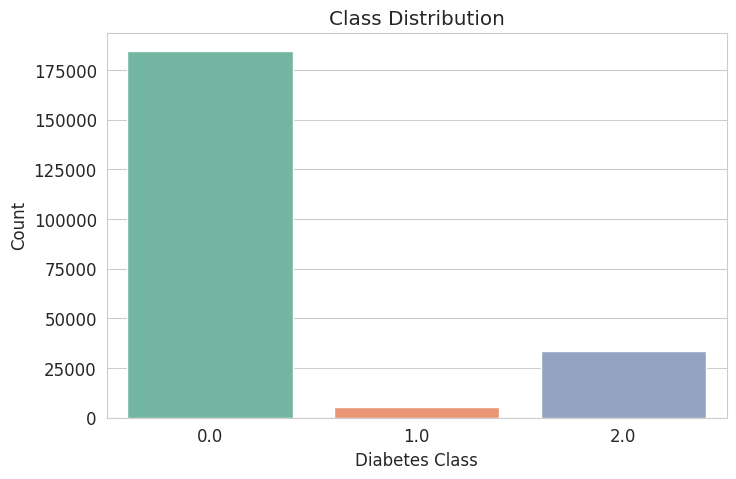

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=y,
    palette="Set2"
)

plt.title("Class Distribution")
plt.xlabel("Diabetes Class")
plt.ylabel("Count")

plt.show()

Feature Selection using Mutual Information

In [28]:
mi_df = pd.DataFrame({
    "Feature":X.columns,
    "Score":mi
})

mi_df = mi_df.sort_values(
    by="Score",
    ascending=False
)

display(mi_df)

,Feature,Score
HighBP,HighBP,0.051956
GenHlth,HighChol,0.047351
PhysActivity,CholCheck,0.044382
CholCheck,BMI,0.043049
AnyHealthcare,Smoker,0.039546
HighChol,Stroke,0.035288
Veggies,HeartDisease,0.034031
Fruits,PhysActivity,0.032470
Age,Fruits,0.029399
BMI,Veggies,0.024271


**Feature Selection using Random Forest**

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X,y)

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

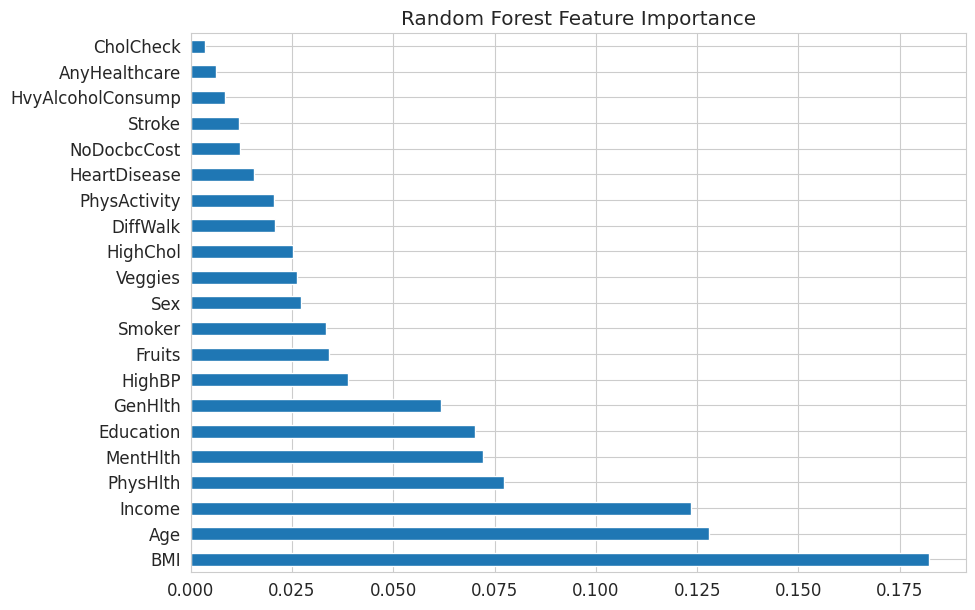

In [30]:
plt.figure(figsize=(10,7))

importance.plot.barh()

plt.title("Random Forest Feature Importance")

plt.show()

Train-Test Split

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("="*60)
print("Training Set Shape")
print(X_train.shape)

print("\nTesting Set Shape")
print(X_test.shape)

Training Set Shape
(178840, 21)

Testing Set Shape
(44710, 21)


In [32]:
print("Training Set Distribution (%)")
print(round(y_train.value_counts(normalize=True) * 100, 2))

print("\nTesting Set Distribution (%)")
print(round(y_test.value_counts(normalize=True) * 100, 2))

Training Set Distribution (%)
Diabetes
0.0    82.55
2.0    14.94
1.0     2.51
Name: proportion, dtype: float64

Testing Set Distribution (%)
Diabetes
0.0    82.55
2.0    14.94
1.0     2.51
Name: proportion, dtype: float64


In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Convert Back to DataFrame

In [34]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

X_train_scaled.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDisease,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
81953,1.148208,-0.834238,0.200280,-1.071371,-0.864161,-0.207275,-0.316119,0.551649,-1.243886,-2.121973,...,0.203639,-0.269397,-0.511716,3.208028,-0.469933,-0.439932,1.048185,0.962433,0.942517,0.492848
162779,-0.870922,-0.834238,0.200280,0.129444,-0.864161,-0.207275,-0.316119,0.551649,0.803932,-2.121973,...,0.203639,-0.269397,-0.511716,-0.516094,-0.469933,-0.439932,1.048185,-1.801663,0.942517,0.072017
35956,-0.870922,-0.834238,-4.993007,-1.371575,1.157192,-0.207275,-0.316119,0.551649,-1.243886,-2.121973,...,-4.910647,3.712000,2.405632,3.208028,3.091610,-0.439932,-0.954030,-1.801663,-0.108223,-1.190476
16296,-0.870922,-0.834238,-4.993007,-0.921269,-0.864161,-0.207275,-0.316119,0.551649,-1.243886,0.471260,...,0.203639,-0.269397,-0.511716,-0.516094,-0.469933,-0.439932,1.048185,-1.494541,-1.158963,0.913679
204748,1.148208,-0.834238,0.200280,0.729852,1.157192,-0.207275,-0.316119,0.551649,0.803932,0.471260,...,0.203639,-0.269397,-0.511716,-0.516094,-0.469933,-0.439932,1.048185,-0.266054,-0.108223,0.913679


In [35]:
X_train_scaled.describe().T[["mean", "std"]]

,mean,std
HighBP,-8.907609e-17,1.000003
HighChol,6.571448e-17,1.000003
CholCheck,-1.989512e-16,1.000003
BMI,-2.220148e-16,1.000003
Smoker,5.959596e-18,1.000003
Stroke,-3.067205e-17,1.000003
HeartDisease,-2.073939e-17,1.000003
PhysActivity,-7.681919e-17,1.000003
Fruits,1.248337e-16,1.000003
Veggies,-1.682990e-16,1.000003


In [36]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


Evaluation Function

In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

results = []

def evaluate_model(model_name, model, X_test, y_test):

    # Predictions
    y_pred = model.predict(X_test)

    # Basic Metrics
    accuracy = accuracy_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    precision_macro = precision_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall_macro = recall_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1_macro = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    precision_weighted = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall_weighted = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1_weighted = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    # Multiclass ROC-AUC (One-vs-Rest)
    try:
        y_prob = model.predict_proba(X_test)

        roc_auc = roc_auc_score(
            y_test,
            y_prob,
            multi_class="ovr",
            average="weighted"
        )

    except:
        roc_auc = np.nan

    # Store Results
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Balanced Accuracy": balanced_acc,
        "Precision (Macro)": precision_macro,
        "Recall (Macro)": recall_macro,
        "F1 Score (Macro)": f1_macro,
        "Precision (Weighted)": precision_weighted,
        "Recall (Weighted)": recall_weighted,
        "F1 Score (Weighted)": f1_weighted,
        "ROC-AUC (OvR)": roc_auc
    })

    print("=" * 70)
    print(f"{model_name}")
    print("=" * 70)

    print(f"Accuracy            : {accuracy:.4f}")
    print(f"Balanced Accuracy   : {balanced_acc:.4f}")
    print(f"Precision (Macro)   : {precision_macro:.4f}")
    print(f"Recall (Macro)      : {recall_macro:.4f}")
    print(f"F1 Score (Macro)    : {f1_macro:.4f}")
    print(f"ROC-AUC (OvR)       : {roc_auc:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    return y_pred

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay

def plot_confusion(model, X_test, y_test):

    plt.figure(figsize=(6,5))

    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        cmap="Blues",
        values_format="d"
    )

    plt.title(type(model).__name__)
    plt.grid(False)

    plt.show()

In [39]:
comparison = pd.DataFrame(
    columns=[
        "Model",
        "Accuracy",
        "Balanced Accuracy",
        "Precision (Macro)",
        "Recall (Macro)",
        "F1 Score (Macro)",
        "Precision (Weighted)",
        "Recall (Weighted)",
        "F1 Score (Weighted)",
        "ROC-AUC (OvR)"
    ]
)

comparison

,Model,Accuracy,Balanced Accuracy,Precision (Macro),Recall (Macro),F1 Score (Macro),Precision (Weighted),Recall (Weighted),F1 Score (Weighted),ROC-AUC (OvR)


Logistic Regression (Baseline)

Logistic Regression
Accuracy            : 0.6190
Balanced Accuracy   : 0.5027
Precision (Macro)   : 0.4405
Recall (Macro)      : 0.5027
F1 Score (Macro)    : 0.4201
ROC-AUC (OvR)       : 0.7916

Classification Report

              precision    recall  f1-score   support

         0.0       0.94      0.63      0.76     36908
         1.0       0.04      0.28      0.07      1123
         2.0       0.35      0.59      0.44      6679

    accuracy                           0.62     44710
   macro avg       0.44      0.50      0.42     44710
weighted avg       0.83      0.62      0.69     44710



<Figure size 600x500 with 0 Axes>

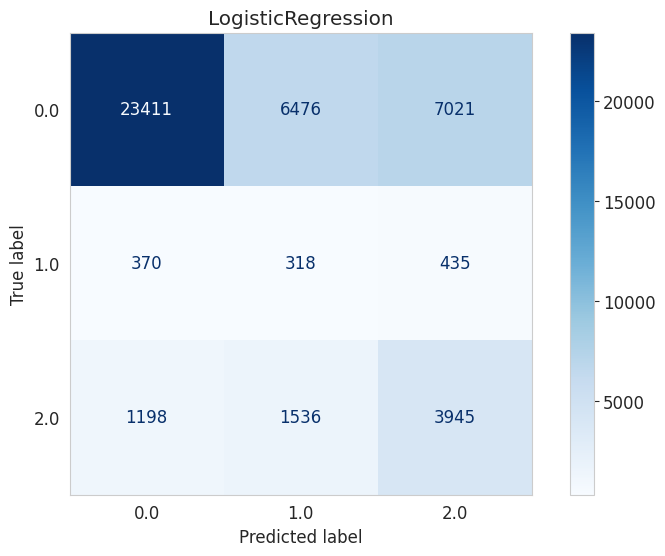

In [40]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42,
    multi_class="multinomial"
)

log_model.fit(
    X_train_scaled,
    y_train
)

evaluate_model(
    "Logistic Regression",
    log_model,
    X_test_scaled,
    y_test
)

plot_confusion(
    log_model,
    X_test_scaled,
    y_test
)

Hyperparameter Tuning - Logistic Regression

In [41]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C":[0.01,0.1,1,10],
    "solver":["lbfgs","newton-cg","saga"]
}

grid = GridSearchCV(
    LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        multi_class="multinomial",
        random_state=42
    ),
    param_grid,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

grid.fit(
    X_train_scaled,
    y_train
)

best_logistic = grid.best_estimator_

print(grid.best_params_)

{'C': 0.01, 'solver': 'lbfgs'}


Evaluate Best Logistic Regression

Logistic Regression (Tuned)
Accuracy            : 0.6190
Balanced Accuracy   : 0.5022
Precision (Macro)   : 0.4404
Recall (Macro)      : 0.5022
F1 Score (Macro)    : 0.4200
ROC-AUC (OvR)       : 0.7916

Classification Report

              precision    recall  f1-score   support

         0.0       0.94      0.63      0.76     36908
         1.0       0.04      0.28      0.07      1123
         2.0       0.35      0.59      0.44      6679

    accuracy                           0.62     44710
   macro avg       0.44      0.50      0.42     44710
weighted avg       0.83      0.62      0.69     44710



<Figure size 600x500 with 0 Axes>

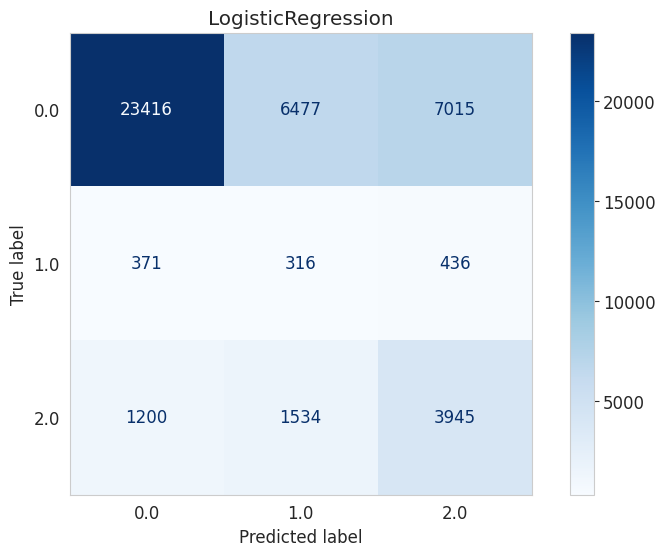

In [42]:
evaluate_model(
    "Logistic Regression (Tuned)",
    best_logistic,
    X_test_scaled,
    y_test
)

plot_confusion(
    best_logistic,
    X_test_scaled,
    y_test
)

**Decision Tree**

Decision Tree
Accuracy            : 0.7369
Balanced Accuracy   : 0.3885
Precision (Macro)   : 0.3860
Recall (Macro)      : 0.3885
F1 Score (Macro)    : 0.3870
ROC-AUC (OvR)       : 0.5796

Classification Report

              precision    recall  f1-score   support

         0.0       0.85      0.84      0.85     36908
         1.0       0.03      0.04      0.03      1123
         2.0       0.28      0.29      0.28      6679

    accuracy                           0.74     44710
   macro avg       0.39      0.39      0.39     44710
weighted avg       0.75      0.74      0.74     44710



<Figure size 600x500 with 0 Axes>

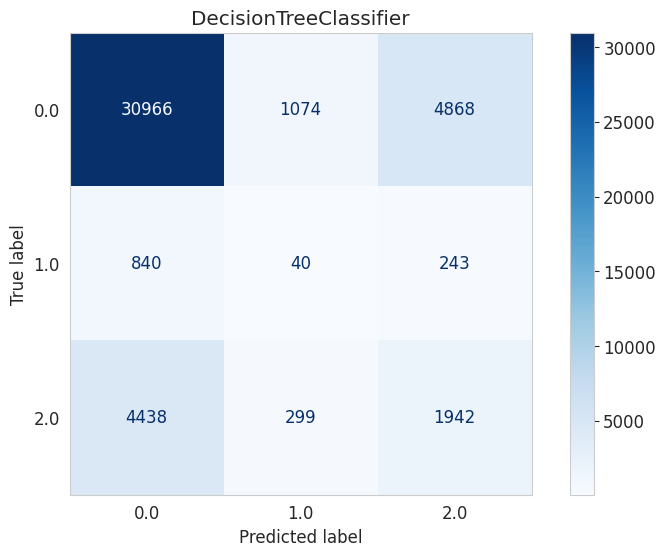

In [43]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

tree.fit(
    X_train,
    y_train
)

evaluate_model(
    "Decision Tree",
    tree,
    X_test,
    y_test
)

plot_confusion(
    tree,
    X_test,
    y_test
)

In [44]:
from sklearn.model_selection import RandomizedSearchCV

params = {

    "criterion":[
        "gini",
        "entropy"
    ],

    "max_depth":[
        5,10,15,20,None
    ],

    "min_samples_split":[
        2,5,10
    ],

    "min_samples_leaf":[
        1,2,4
    ]

}

search = RandomizedSearchCV(

    tree,

    params,

    cv=cv,

    scoring="f1_weighted",

    n_iter=15,

    random_state=42,

    n_jobs=-1

)

search.fit(
    X_train,
    y_train
)

best_tree = search.best_estimator_

print(search.best_params_)

{'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None, 'criterion': 'entropy'}


Decision Tree (Tuned)
Accuracy            : 0.7386
Balanced Accuracy   : 0.3954
Precision (Macro)   : 0.3915
Recall (Macro)      : 0.3954
F1 Score (Macro)    : 0.3931
ROC-AUC (OvR)       : 0.5863

Classification Report

              precision    recall  f1-score   support

         0.0       0.86      0.84      0.85     36908
         1.0       0.03      0.04      0.04      1123
         2.0       0.28      0.30      0.29      6679

    accuracy                           0.74     44710
   macro avg       0.39      0.40      0.39     44710
weighted avg       0.75      0.74      0.74     44710



<Figure size 600x500 with 0 Axes>

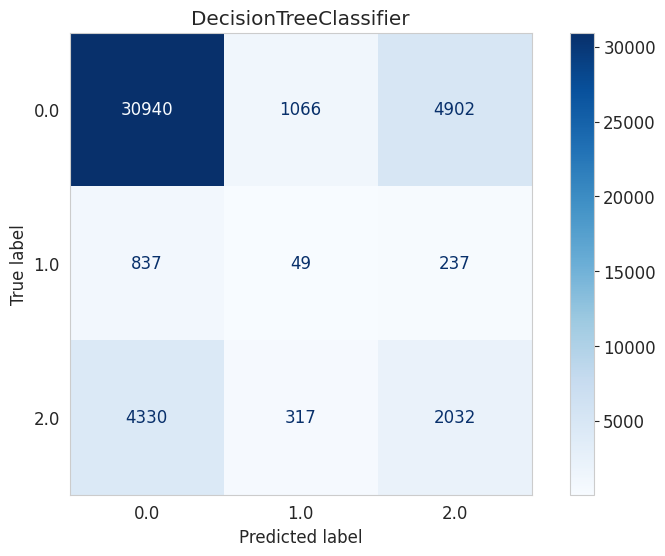

In [45]:
evaluate_model(
    "Decision Tree (Tuned)",
    best_tree,
    X_test,
    y_test
)

plot_confusion(
    best_tree,
    X_test,
    y_test
)

**Random Forest**

Random Forest
Accuracy            : 0.8247
Balanced Accuracy   : 0.3755
Precision (Macro)   : 0.4403
Recall (Macro)      : 0.3755
F1 Score (Macro)    : 0.3792
ROC-AUC (OvR)       : 0.7669

Classification Report

              precision    recall  f1-score   support

         0.0       0.84      0.97      0.90     36908
         1.0       0.00      0.00      0.00      1123
         2.0       0.48      0.16      0.23      6679

    accuracy                           0.82     44710
   macro avg       0.44      0.38      0.38     44710
weighted avg       0.77      0.82      0.78     44710



<Figure size 600x500 with 0 Axes>

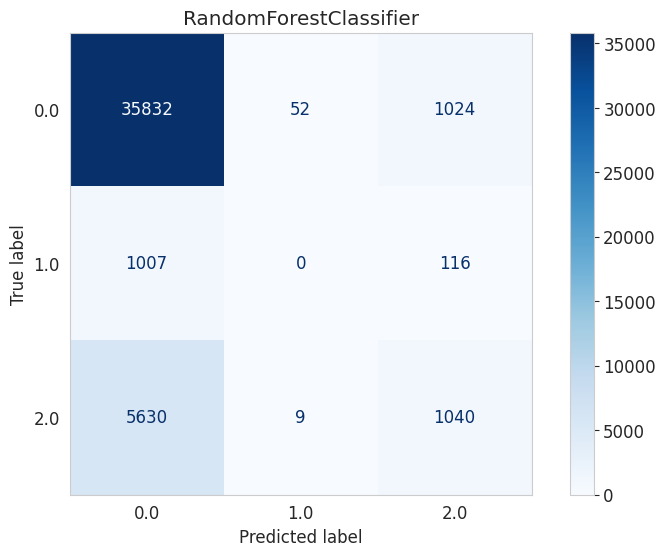

In [46]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(

    n_estimators=300,

    random_state=42,

    class_weight="balanced",

    n_jobs=-1

)

rf.fit(
    X_train,
    y_train
)

evaluate_model(
    "Random Forest",
    rf,
    X_test,
    y_test
)

plot_confusion(
    rf,
    X_test,
    y_test
)

In [47]:
params = {

    "n_estimators":[
        200,
        300,
        500
    ],

    "max_depth":[
        10,
        20,
        None
    ],

    "min_samples_leaf":[
        1,
        2,
        4
    ],

    "max_features":[
        "sqrt",
        "log2"
    ]

}

search = RandomizedSearchCV(

    rf,

    params,

    cv=cv,

    n_iter=15,

    scoring="f1_weighted",

    random_state=42,

    n_jobs=-1

)

search.fit(
    X_train,
    y_train
)

best_rf = search.best_estimator_

print(search.best_params_)

{'n_estimators': 300, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}


Random Forest (Tuned)
Accuracy            : 0.8021
Balanced Accuracy   : 0.4460
Precision (Macro)   : 0.4421
Recall (Macro)      : 0.4460
F1 Score (Macro)    : 0.4394
ROC-AUC (OvR)       : 0.7852

Classification Report

              precision    recall  f1-score   support

         0.0       0.88      0.89      0.89     36908
         1.0       0.04      0.00      0.01      1123
         2.0       0.41      0.44      0.43      6679

    accuracy                           0.80     44710
   macro avg       0.44      0.45      0.44     44710
weighted avg       0.79      0.80      0.79     44710



<Figure size 600x500 with 0 Axes>

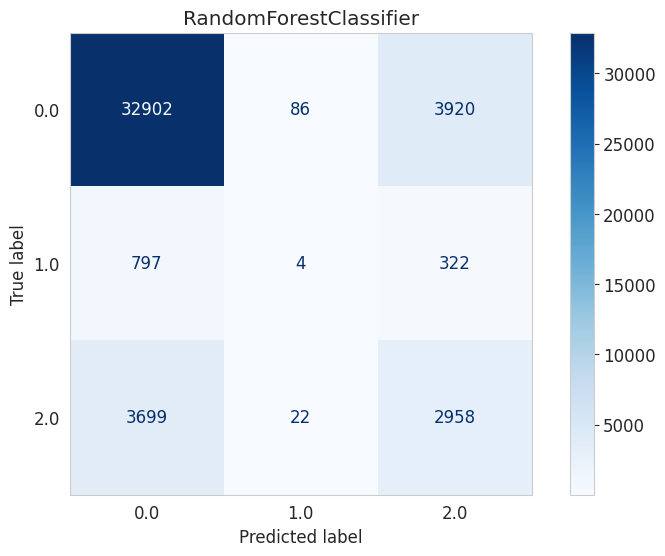

In [48]:
evaluate_model(
    "Random Forest (Tuned)",
    best_rf,
    X_test,
    y_test
)

plot_confusion(
    best_rf,
    X_test,
    y_test
)

Compare Result

In [49]:
comparison = pd.DataFrame(results)

comparison.sort_values(
    by="F1 Score (Weighted)",
    ascending=False,
    inplace=True
)

comparison.reset_index(
    drop=True,
    inplace=True
)

comparison.style.background_gradient(
    cmap="Greens"
)

,Model,Accuracy,Balanced Accuracy,Precision (Macro),Recall (Macro),F1 Score (Macro),Precision (Weighted),Recall (Weighted),F1 Score (Weighted),ROC-AUC (OvR)
0,Random Forest (Tuned),0.802147,0.445967,0.442109,0.445967,0.439438,0.788525,0.802147,0.794884,0.785169
1,Random Forest,0.824692,0.375519,0.440262,0.375519,0.379207,0.767756,0.824692,0.780359,0.766885
2,Decision Tree (Tuned),0.738560,0.395390,0.391493,0.395390,0.393094,0.750557,0.738560,0.744404,0.586282
3,Decision Tree,0.736927,0.388462,0.386009,0.388462,0.387003,0.747129,0.736927,0.741928,0.579582
4,Logistic Regression (Tuned),0.619034,0.502163,0.440417,0.502163,0.420010,0.826263,0.619034,0.691490,0.791570
5,Logistic Regression,0.618967,0.502711,0.440475,0.502711,0.420082,0.826328,0.618967,0.691429,0.791559


**KNN**

KNN
Accuracy            : 0.8081
Balanced Accuracy   : 0.3839
Precision (Macro)   : 0.4180
Recall (Macro)      : 0.3839
F1 Score (Macro)    : 0.3884
ROC-AUC (OvR)       : 0.7083

Classification Report

              precision    recall  f1-score   support

         0.0       0.85      0.94      0.89     36908
         1.0       0.03      0.00      0.00      1123
         2.0       0.38      0.21      0.27      6679

    accuracy                           0.81     44710
   macro avg       0.42      0.38      0.39     44710
weighted avg       0.76      0.81      0.78     44710



<Figure size 600x500 with 0 Axes>

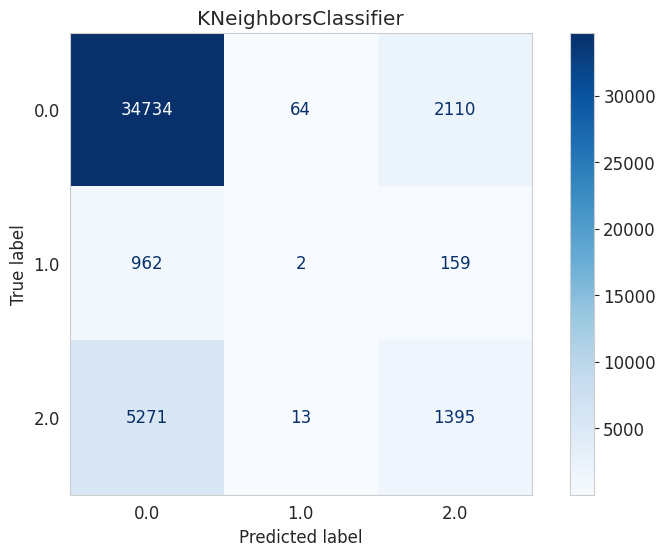

In [50]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=7,
    weights="distance"
)

knn.fit(
    X_train_scaled,
    y_train
)

evaluate_model(
    "KNN",
    knn,
    X_test_scaled,
    y_test
)

plot_confusion(
    knn,
    X_test_scaled,
    y_test
)

In [51]:
params = {
    "n_neighbors":[3,5,7,9,11],
    "weights":["uniform","distance"],
    "metric":["euclidean","manhattan"]
}

search = GridSearchCV(
    KNeighborsClassifier(),
    params,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

search.fit(
    X_train_scaled,
    y_train
)

best_knn = search.best_estimator_

print(search.best_params_)

{'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}


KNN (Tuned)
Accuracy            : 0.8193
Balanced Accuracy   : 0.3819
Precision (Macro)   : 0.4258
Recall (Macro)      : 0.3819
F1 Score (Macro)    : 0.3867
ROC-AUC (OvR)       : 0.7181

Classification Report

              precision    recall  f1-score   support

         0.0       0.85      0.96      0.90     36908
         1.0       0.00      0.00      0.00      1123
         2.0       0.43      0.19      0.26      6679

    accuracy                           0.82     44710
   macro avg       0.43      0.38      0.39     44710
weighted avg       0.76      0.82      0.78     44710



<Figure size 600x500 with 0 Axes>

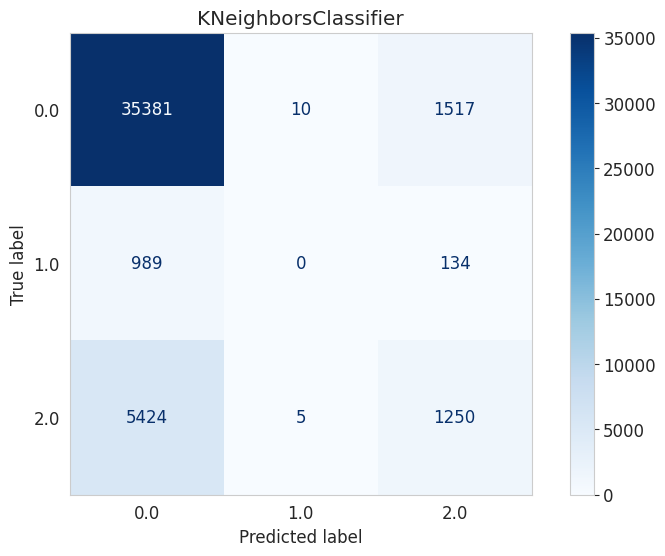

In [52]:
evaluate_model(
    "KNN (Tuned)",
    best_knn,
    X_test_scaled,
    y_test
)

plot_confusion(
    best_knn,
    X_test_scaled,
    y_test
)

**SVM**

In [53]:
from sklearn.svm import LinearSVC

linear_svm = LinearSVC(
    C=1.0,
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

linear_svm.fit(
    X_train_scaled,
    y_train
)

LinearSVC(class_weight='balanced', max_iter=5000, random_state=42)

Linear SVM
Accuracy            : 0.8005
Balanced Accuracy   : 0.4509
Precision (Macro)   : 0.4301
Recall (Macro)      : 0.4509
F1 Score (Macro)    : 0.4398
ROC-AUC (OvR)       : nan

Classification Report

              precision    recall  f1-score   support

         0.0       0.88      0.89      0.88     36908
         1.0       0.00      0.00      0.00      1123
         2.0       0.41      0.47      0.44      6679

    accuracy                           0.80     44710
   macro avg       0.43      0.45      0.44     44710
weighted avg       0.79      0.80      0.79     44710



<Figure size 600x500 with 0 Axes>

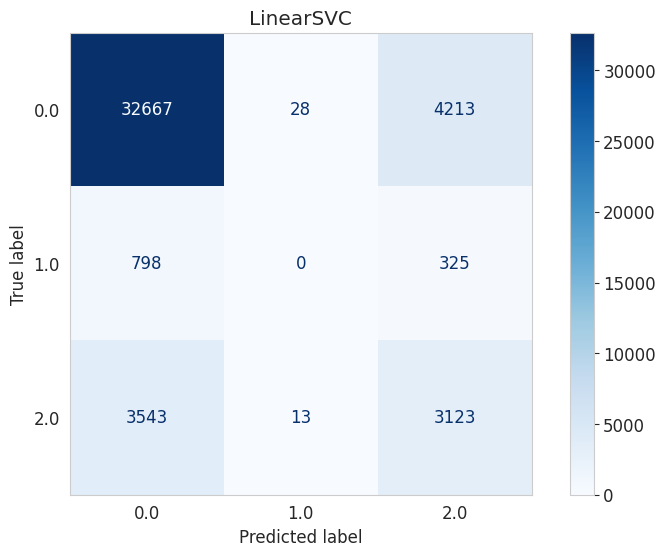

In [54]:
evaluate_model(
    "Linear SVM",
    linear_svm,
    X_test_scaled,
    y_test
)

plot_confusion(
    linear_svm,
    X_test_scaled,
    y_test
)

In [55]:
from sklearn.model_selection import GridSearchCV

svm_params = {
    "C": [0.1, 1.0, 10.0]
}

svm_search = GridSearchCV(
    estimator=LinearSVC(
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    ),
    param_grid=svm_params,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

svm_search.fit(
    X_train_scaled,
    y_train
)

best_svm = svm_search.best_estimator_

print("Best parameters:", svm_search.best_params_)

Best parameters: {'C': 0.1}


Linear SVM (Tuned)
Accuracy            : 0.8005
Balanced Accuracy   : 0.4509
Precision (Macro)   : 0.4301
Recall (Macro)      : 0.4509
F1 Score (Macro)    : 0.4398
ROC-AUC (OvR)       : nan

Classification Report

              precision    recall  f1-score   support

         0.0       0.88      0.89      0.88     36908
         1.0       0.00      0.00      0.00      1123
         2.0       0.41      0.47      0.44      6679

    accuracy                           0.80     44710
   macro avg       0.43      0.45      0.44     44710
weighted avg       0.79      0.80      0.79     44710



<Figure size 600x500 with 0 Axes>

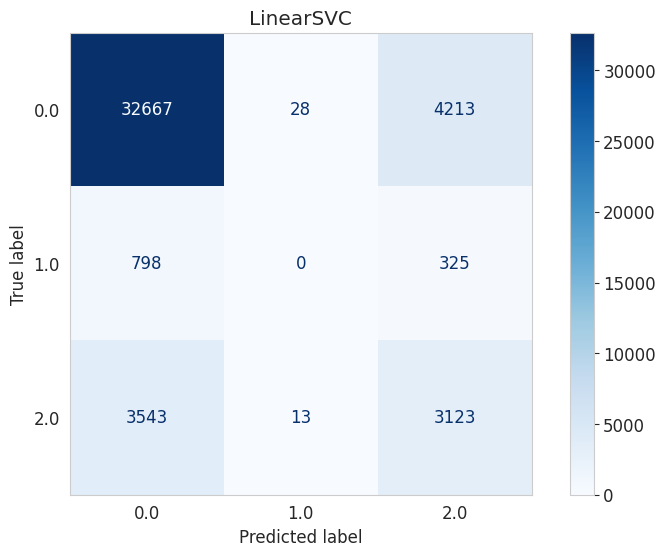

In [56]:
evaluate_model(
    "Linear SVM (Tuned)",
    best_svm,
    X_test_scaled,
    y_test
)

plot_confusion(
    best_svm,
    X_test_scaled,
    y_test
)

**XGBoost**

XGBoost
Accuracy            : 0.8338
Balanced Accuracy   : 0.3871
Precision (Macro)   : 0.4692
Recall (Macro)      : 0.3871
F1 Score (Macro)    : 0.3952
ROC-AUC (OvR)       : 0.8011

Classification Report

              precision    recall  f1-score   support

         0.0       0.85      0.98      0.91     36908
         1.0       0.00      0.00      0.00      1123
         2.0       0.56      0.18      0.28      6679

    accuracy                           0.83     44710
   macro avg       0.47      0.39      0.40     44710
weighted avg       0.78      0.83      0.79     44710



<Figure size 600x500 with 0 Axes>

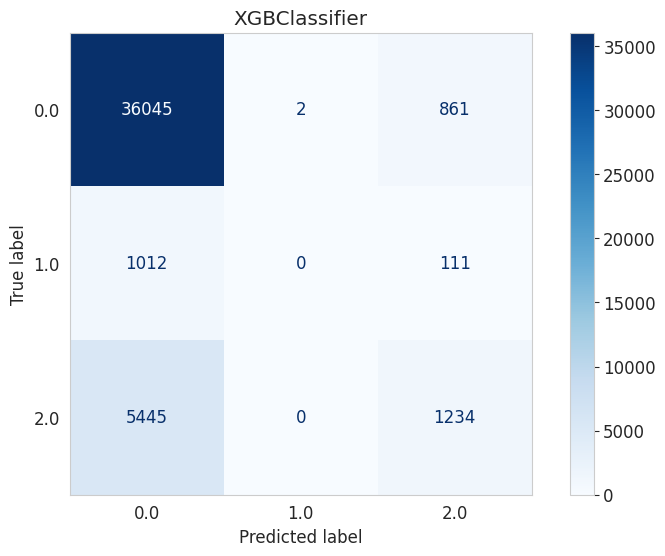

In [57]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6
)

xgb.fit(
    X_train,
    y_train
)

evaluate_model(
    "XGBoost",
    xgb,
    X_test,
    y_test
)

plot_confusion(
    xgb,
    X_test,
    y_test
)

CatBoost

CatBoost
Accuracy            : 0.8326
Balanced Accuracy   : 0.3880
Precision (Macro)   : 0.4645
Recall (Macro)      : 0.3880
F1 Score (Macro)    : 0.3962
ROC-AUC (OvR)       : 0.7996

Classification Report

              precision    recall  f1-score   support

         0.0       0.85      0.97      0.91     36908
         1.0       0.00      0.00      0.00      1123
         2.0       0.54      0.19      0.28      6679

    accuracy                           0.83     44710
   macro avg       0.46      0.39      0.40     44710
weighted avg       0.78      0.83      0.79     44710



<Figure size 600x500 with 0 Axes>

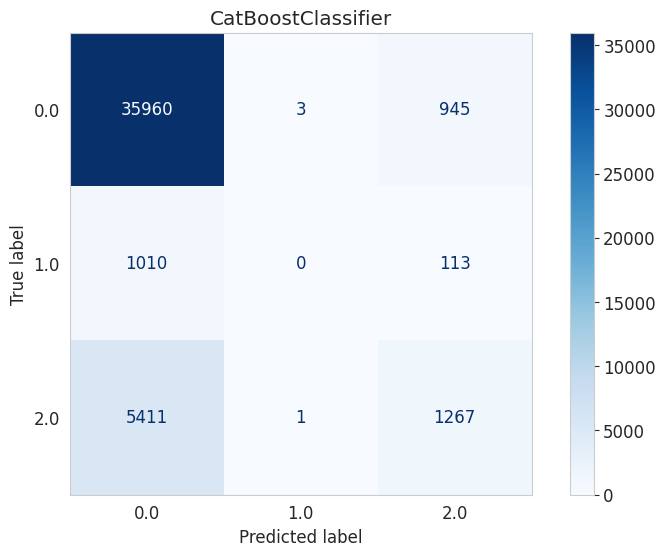

In [58]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=300,
    random_seed=42,
    verbose=False
)

cat.fit(
    X_train,
    y_train
)

evaluate_model(
    "CatBoost",
    cat,
    X_test,
    y_test
)

plot_confusion(
    cat,
    X_test,
    y_test
)

In [59]:
comparison = pd.DataFrame(results)

comparison = comparison.sort_values(
    by="F1 Score (Weighted)",
    ascending=False
)

comparison.reset_index(
    drop=True,
    inplace=True
)

comparison

,Model,Accuracy,Balanced Accuracy,Precision (Macro),Recall (Macro),F1 Score (Macro),Precision (Weighted),Recall (Weighted),F1 Score (Weighted),ROC-AUC (OvR)
0,Random Forest (Tuned),0.802147,0.445967,0.442109,0.445967,0.439438,0.788525,0.802147,0.794884,0.785169
1,Linear SVM,0.800492,0.450893,0.430117,0.450893,0.439820,0.789564,0.800492,0.794720,NaN
2,Linear SVM (Tuned),0.800492,0.450893,0.430117,0.450893,0.439820,0.789564,0.800492,0.794720,NaN
3,XGBoost,0.833796,0.387125,0.469154,0.387125,0.395197,0.783650,0.833796,0.790898,0.801116
4,CatBoost,0.832633,0.388005,0.464480,0.388005,0.396164,0.781836,0.832633,0.790819,0.799643
5,KNN (Tuned),0.819302,0.381927,0.425814,0.381927,0.386691,0.763199,0.819302,0.781199,0.718116
6,Random Forest,0.824692,0.375519,0.440262,0.375519,0.379207,0.767756,0.824692,0.780359,0.766885
7,KNN,0.808119,0.383914,0.417967,0.383914,0.388373,0.757412,0.808119,0.776761,0.708270
8,Decision Tree (Tuned),0.738560,0.395390,0.391493,0.395390,0.393094,0.750557,0.738560,0.744404,0.586282
9,Decision Tree,0.736927,0.388462,0.386009,0.388462,0.387003,0.747129,0.736927,0.741928,0.579582


In [60]:
comparison.style.background_gradient(
    cmap="Greens"
)

,Model,Accuracy,Balanced Accuracy,Precision (Macro),Recall (Macro),F1 Score (Macro),Precision (Weighted),Recall (Weighted),F1 Score (Weighted),ROC-AUC (OvR)
0,Random Forest (Tuned),0.802147,0.445967,0.442109,0.445967,0.439438,0.788525,0.802147,0.794884,0.785169
1,Linear SVM,0.800492,0.450893,0.430117,0.450893,0.439820,0.789564,0.800492,0.794720,nan
2,Linear SVM (Tuned),0.800492,0.450893,0.430117,0.450893,0.439820,0.789564,0.800492,0.794720,nan
3,XGBoost,0.833796,0.387125,0.469154,0.387125,0.395197,0.783650,0.833796,0.790898,0.801116
4,CatBoost,0.832633,0.388005,0.464480,0.388005,0.396164,0.781836,0.832633,0.790819,0.799643
5,KNN (Tuned),0.819302,0.381927,0.425814,0.381927,0.386691,0.763199,0.819302,0.781199,0.718116
6,Random Forest,0.824692,0.375519,0.440262,0.375519,0.379207,0.767756,0.824692,0.780359,0.766885
7,KNN,0.808119,0.383914,0.417967,0.383914,0.388373,0.757412,0.808119,0.776761,0.708270
8,Decision Tree (Tuned),0.738560,0.395390,0.391493,0.395390,0.393094,0.750557,0.738560,0.744404,0.586282
9,Decision Tree,0.736927,0.388462,0.386009,0.388462,0.387003,0.747129,0.736927,0.741928,0.579582


In [61]:
best_model_name = comparison.iloc[0]["Model"]

print(f"Best Model : {best_model_name}")

Best Model : Random Forest (Tuned)


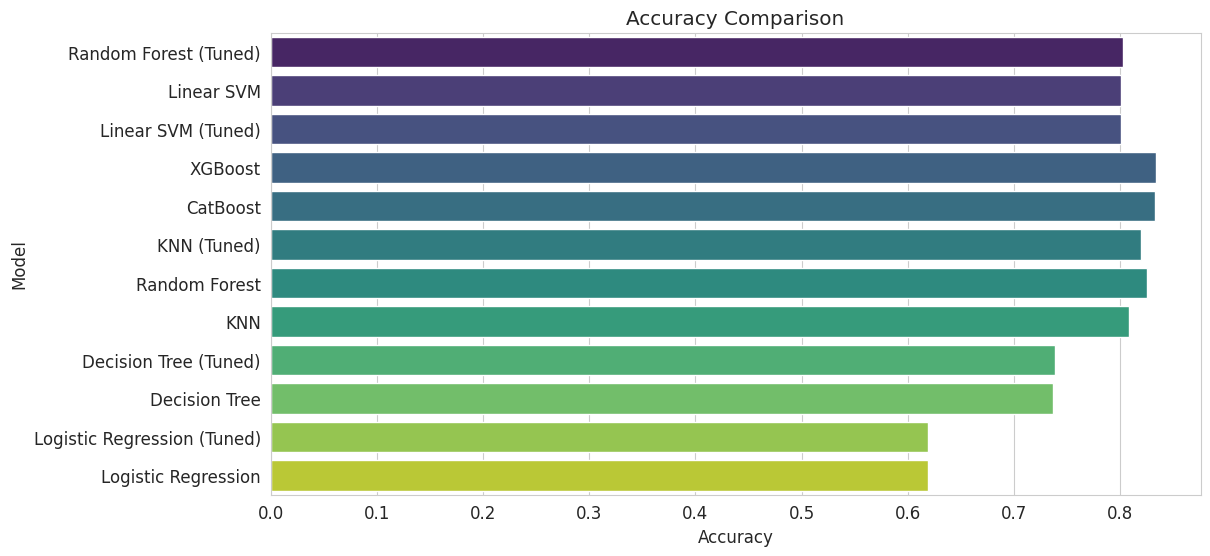

In [62]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=comparison,
    x="Accuracy",
    y="Model",
    palette="viridis"
)

plt.title("Accuracy Comparison")

plt.show()

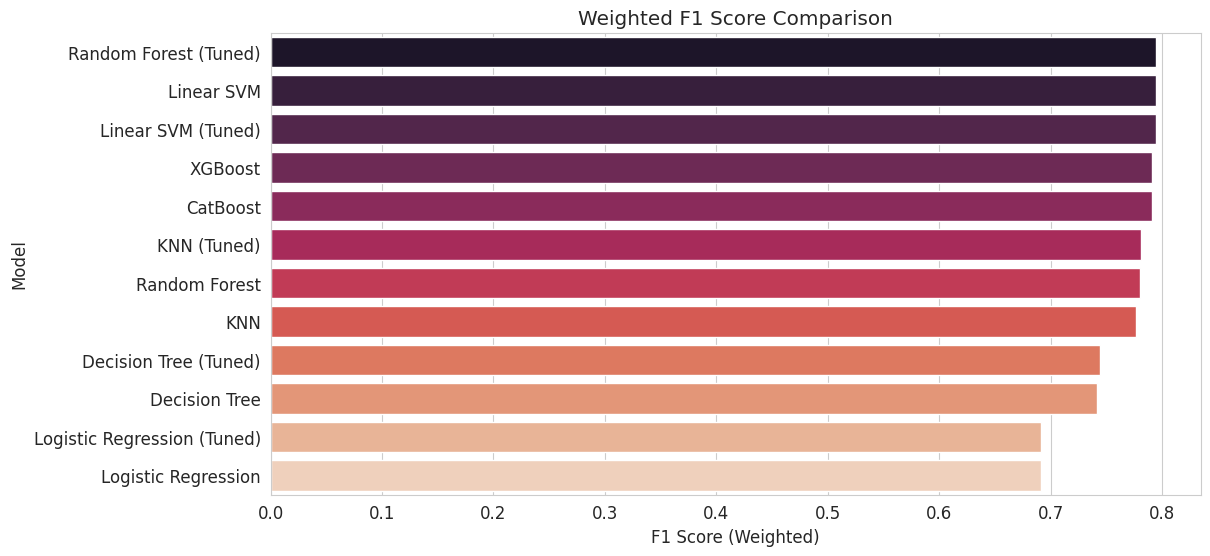

In [63]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=comparison,
    x="F1 Score (Weighted)",
    y="Model",
    palette="rocket"
)

plt.title("Weighted F1 Score Comparison")

plt.show()

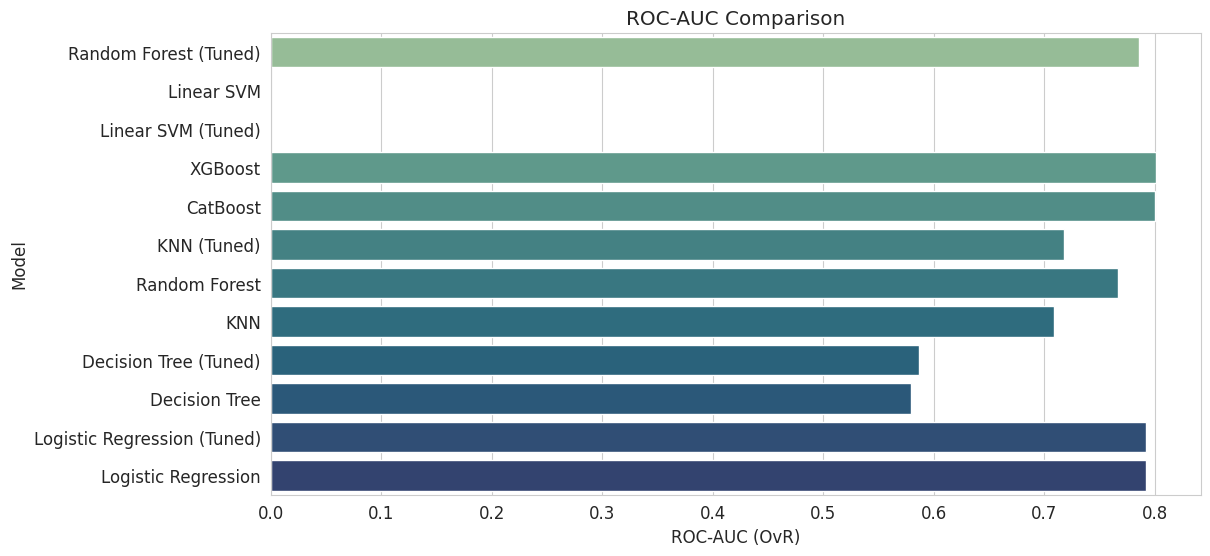

In [64]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=comparison,
    x="ROC-AUC (OvR)",
    y="Model",
    palette="crest"
)

plt.title("ROC-AUC Comparison")

plt.show()

In [65]:
import shap
import numpy as np

shap.initjs()

In [66]:
X_sample = X_test.sample(
    n=min(1000, len(X_test)),
    random_state=42
)

print("Sample shape:", X_sample.shape)

Sample shape: (1000, 21)


In [67]:
explainer = shap.TreeExplainer(xgb)

shap_values = explainer(X_sample)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (1000, 21, 3)


In [68]:
class_names = [
    "No Diabetes",
    "Prediabetes",
    "Diabetes"
]

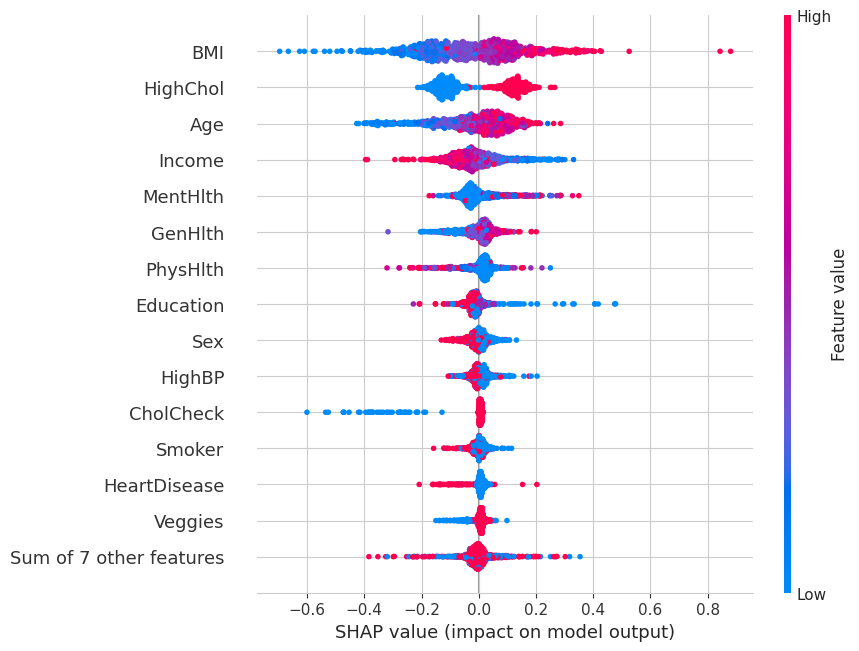

In [69]:
shap.plots.beeswarm(
    shap_values[:, :, 1],
    max_display=15
)

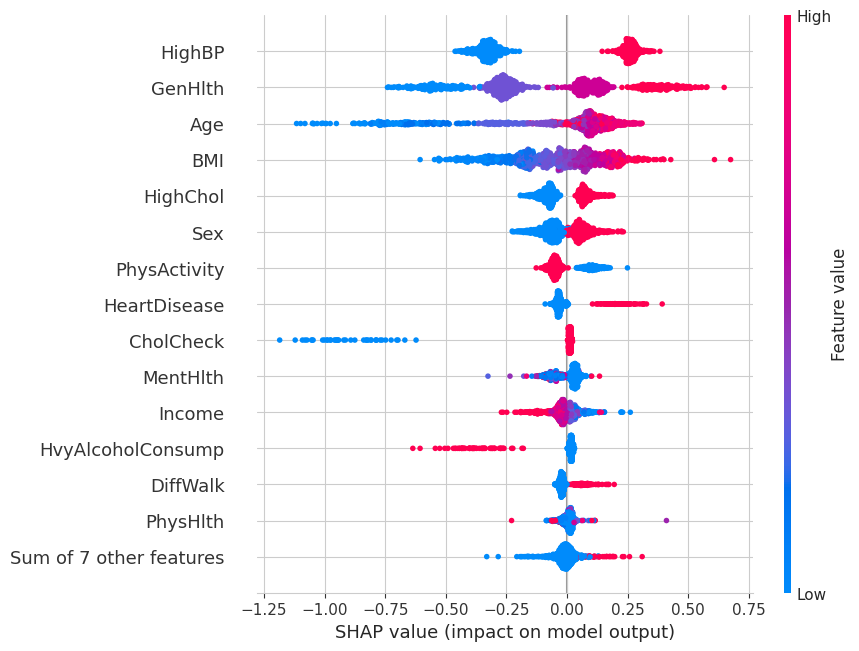

In [70]:
shap.plots.beeswarm(
    shap_values[:, :, 2],
    max_display=15
)

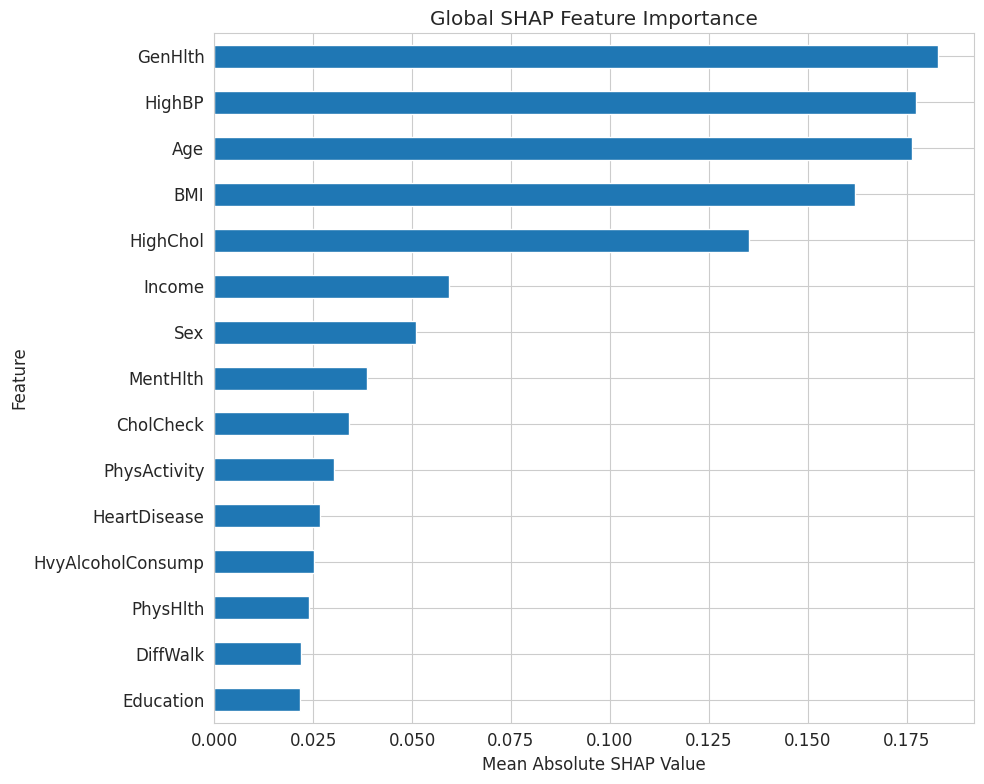

In [71]:
global_importance = np.abs(
    shap_values.values
).mean(axis=(0, 2))

shap_importance = pd.Series(
    global_importance,
    index=X_sample.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 8))

shap_importance.tail(15).plot(
    kind="barh"
)

plt.title("Global SHAP Feature Importance")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [72]:
assert len(X.columns) == 21, "Expected 21 features"

assert list(X_train.columns) == list(X_test.columns), \
    "Train and test columns do not match"

assert set(y.unique()) == {0, 1, 2}, \
    "Expected classes 0, 1, and 2"

assert not X.isnull().any().any(), \
    "Missing values found"

test_prediction = xgb.predict(X_test.iloc[[0]])

assert int(test_prediction[0]) in {0, 1, 2}, \
    "Unexpected prediction class"

print("All final checks passed successfully!")

All final checks passed successfully!


In [73]:
xgb.save_model("xgboost_diabetes_model.json")

print("Model saved successfully!")

Model saved successfully!


In [74]:
import json

metadata = {
    "model_name": "XGBoost Multiclass Diabetes Prediction",

    "classes": {
        "0": "No Diabetes",
        "1": "Prediabetes",
        "2": "Diabetes"
    },

    "feature_names": list(X.columns),

    "number_of_features": len(X.columns)
}

with open("model_metadata.json", "w") as file:
    json.dump(metadata, file, indent=4)

print("Metadata saved successfully!")

Metadata saved successfully!


In [75]:
class_labels = {
    0: "No Diabetes",
    1: "Prediabetes",
    2: "Diabetes"
}

def predict_diabetes(model, patient_data):

    # Make sure columns are in correct order
    patient_data = patient_data[X.columns]

    # Predict class
    prediction = int(model.predict(patient_data)[0])

    # Get probabilities
    probabilities = model.predict_proba(patient_data)[0]

    return {
        "prediction": class_labels[prediction],

        "confidence": float(
            probabilities[prediction]
        ),

        "probabilities": {
            class_labels[i]: float(probabilities[i])
            for i in range(3)
        }
    }

In [76]:
sample_patient = X_test.iloc[[0]]

result = predict_diabetes(
    xgb,
    sample_patient
)

print("Prediction:", result["prediction"])

print(
    f"Confidence: {result['confidence']:.2%}"
)

print("\nAll probabilities:")

for label, probability in result["probabilities"].items():
    print(f"{label}: {probability:.2%}")

Prediction: No Diabetes
Confidence: 97.99%

All probabilities:
No Diabetes: 97.99%
Prediabetes: 0.48%
Diabetes: 1.53%
